Overview:El objetivo de la tienda online es aumentar los ingresos por lo que tendremos que tendremos que priorizar hipótesis,análisis de prueba A/B y detección de anomalías para poder tomar una decisión final junto al equipo de marketing

Vamos a cargar los archivos para verificar los tipos de datos 

In [1]:
import pandas as pd

hypotheses=pd.read_csv('/datasets/hypotheses_us.csv',sep=';')
orders=pd.read_csv('/datasets/orders_us.csv')
visits=pd.read_csv('/datasets/visits_us.csv')

print(hypotheses.info())
print(orders.info())
print(visits.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data col

In [2]:
#Convertimos las columnas de fecha al formato datetime para poder trabajar con ellas 
orders['date']=pd.to_datetime(orders['date'])
visits['date']=pd.to_datetime(visits['date'])
print(visits.info())
print(orders.info())
#Revisamos que no haya valores duplicados en los grupos y convertimos a minúsculas los nombres de las columnas
hypotheses.columns=hypotheses.columns.str.lower()
print(visits.isna().sum())
print(orders.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    62 non-null     datetime64[ns]
 1   group   62 non-null     object        
 2   visits  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1197 non-null   int64         
 1   visitorId      1197 non-null   int64         
 2   date           1197 non-null   datetime64[ns]
 3   revenue        1197 non-null   float64       
 4   group          1197 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 46.9+ KB
None
date      0
group     0
visits    0
dtype: int64
trans

Ahora priorizaremos Hipótesis calculando ICE y RICE

In [3]:
#Agregamos la columna ICE /RICE
hypotheses['ICE']=(hypotheses['impact'] * hypotheses['confidence'] / hypotheses['effort'])
hypotheses['RICE']=(hypotheses['reach'] * hypotheses['impact'] * hypotheses['confidence']) / hypotheses['effort']
print(hypotheses[['hypothesis','ICE', 'RICE']].sort_values(by='ICE',ascending=False))

                                          hypothesis        ICE   RICE
8  Launch a promotion that gives users discounts ...  16.200000   16.2
0  Add two new channels for attracting traffic. T...  13.333333   40.0
7  Add a subscription form to all the main pages....  11.200000  112.0
6  Show banners with current offers and sales on ...   8.000000   40.0
2  Add product recommendation blocks to the store...   7.000000   56.0
1  Launch your own delivery service. This will sh...   2.000000    4.0
5  Add a customer review page. This will increase...   1.333333    4.0
3  Change the category structure. This will incre...   1.125000    9.0
4  Change the background color on the main page. ...   1.000000    3.0


La hipótesis 8 es la ganadora de ICE mientras que para RICE la ganadora es la 7. Debemos poner especial atención en la 7 ya que afecta acada individuo que entra a la tienda en linea en todfas las páginas principales y a largo plazo generará más valor e ingresos acumulados que la 8.

In [4]:
import numpy as np
# Creamos una matriz con las fechas y grupos únicos de la tabla orders
datesGroups = orders[['date','group']].drop_duplicates()

# Obtenemos los datos acumulados diarios de las órdenes
ordersAggregated = datesGroups.apply(
    lambda x: orders[np.logical_not(orders['date'] > x['date']) & (orders['group'] == x['group'])]
    .agg({'date' : 'max', 'group' : 'max', 'transactionId' : 'nunique', 'visitorId' : 'nunique', 'revenue' : 'sum'}), 
    axis=1
).sort_values(by=['date','group'])

# Obtenemos los datos acumulados diarios de las visitas
visitsAggregated = datesGroups.apply(
    lambda x: visits[np.logical_not(visits['date'] > x['date']) & (visits['group'] == x['group'])]
    .agg({'date' : 'max', 'group' : 'max', 'visits' : 'sum'}), 
    axis=1
).sort_values(by=['date','group'])

# Fusionamos las dos tablas en un solo dataframe 
cumulativeData = pd.merge(ordersAggregated, visitsAggregated, left_on=['date', 'group'], right_on=['date', 'group'])
cumulativeData.columns = ['date', 'group', 'orders', 'buyers', 'revenue', 'visits']


print(cumulativeData.head(10))

        date group  orders  buyers  revenue  visits
0 2019-08-01     A      24      20   2356.8     719
1 2019-08-01     B      21      20   1620.0     713
2 2019-08-02     A      44      38   3860.3    1338
3 2019-08-02     B      45      43   4243.8    1294
4 2019-08-03     A      68      62   5675.5    1845
5 2019-08-03     B      61      59   6050.6    1803
6 2019-08-04     A      84      77   6822.1    2562
7 2019-08-04     B      78      75   7767.9    2573
8 2019-08-05     A     109     100   8810.2    3318
9 2019-08-05     B     101      98   9262.9    3280


In [5]:
# Dividir en grupos 
cumulativeRevenueA = cumulativeData[cumulativeData['group'] == 'A']
cumulativeRevenueB = cumulativeData[cumulativeData['group'] == 'B']

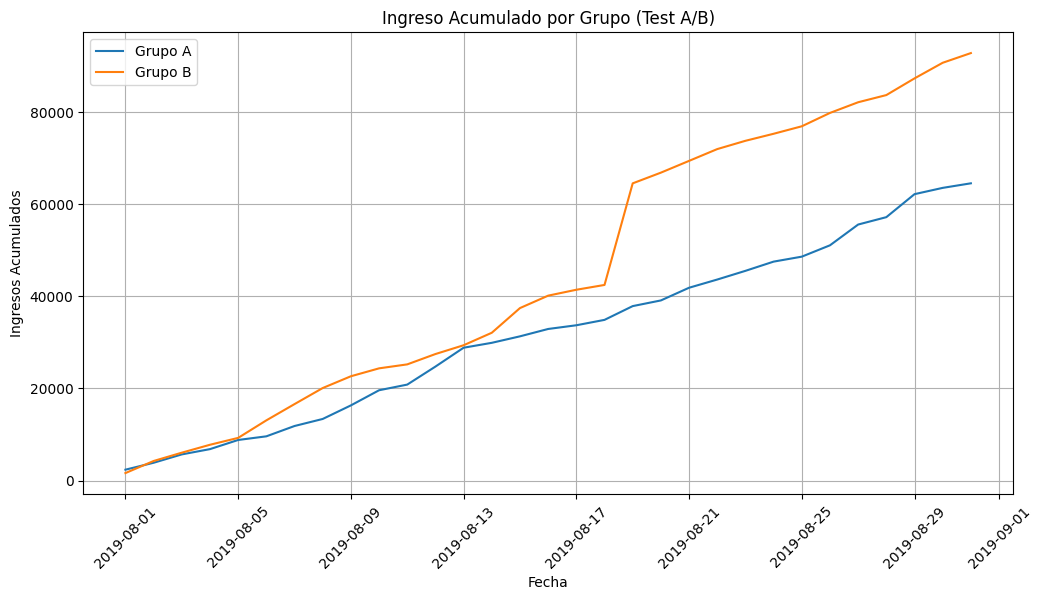

In [6]:
#Vamos a crear la gráfica del ingreso cumulado
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Trazamos la línea de ingresos acumulados para el Grupo A
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue'], label='Grupo A')

# Trazamos la línea de ingresos acumulados para el Grupo B
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue'], label='Grupo B')


plt.title('Ingreso Acumulado por Grupo (Test A/B)')
plt.xlabel('Fecha')
plt.ylabel('Ingresos Acumulados')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()


Ambos grupos mantienen un crecimiento acumulado hasta el 17 de agosto y el 21 porque hay un pico inesperado del grupo B. Debemos analizar este pico porque fue un ingreso acumulado muy alto, de 40,000 a más de 60,000.Podemos asumir que tenemos valores atípicos en esas fechas.

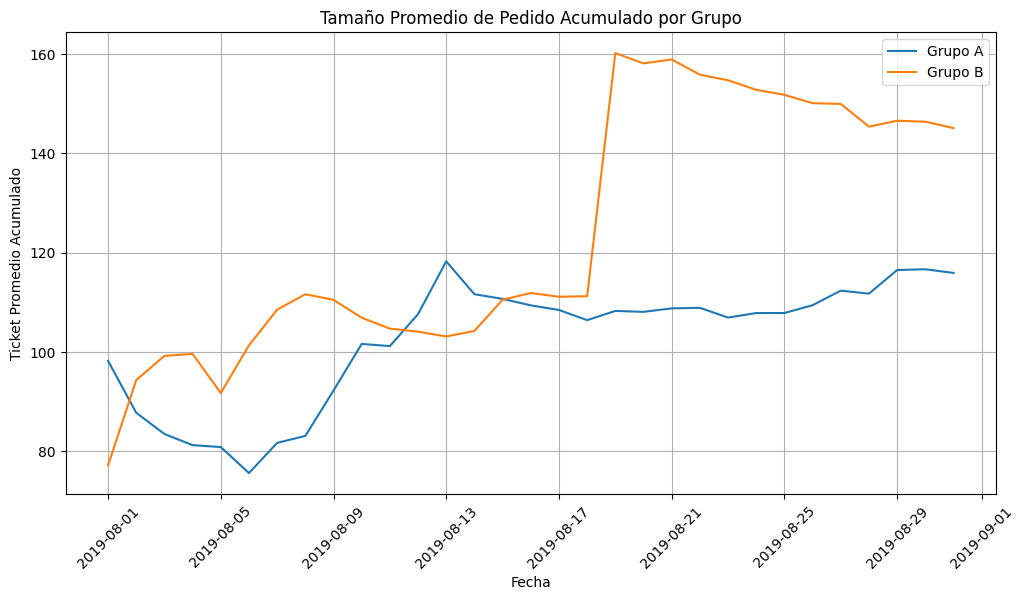

In [7]:
#Vamos a calcular el tamaño de pedido promedio acumulado

plt.figure(figsize=(12, 6))
# Graficamos dividiendo el ingreso acumulado entre el número de órdenes acumuladas
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue'] / cumulativeRevenueA['orders'], label='Grupo A')
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue'] / cumulativeRevenueB['orders'], label='Grupo B')


plt.title('Tamaño Promedio de Pedido Acumulado por Grupo')
plt.xlabel('Fecha')
plt.ylabel('Ticket Promedio Acumulado')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

Podemos ver en la gráfica que en la primera mitad de Agosto ambos grupos fluctuan y es hasta 17 y 21 de Agosto donde el grupo B tiene un pico al alza igual que en el ingreso acumulado lo que nos muestra que fue por una o varias transacciones de un valor elevado.

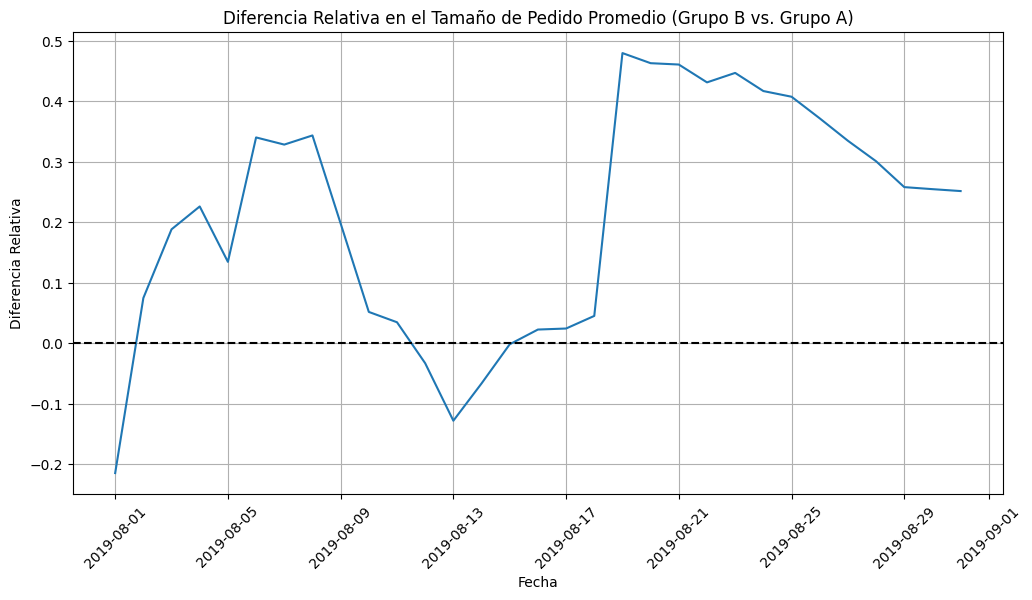

In [8]:
#Vamos a calcular la diferencia relativa en el tamaño promedio de pedido
# Fusionamos los datos acumulados en un solo dataframe para comparar
mergedCumulativeRevenue = pd.merge(cumulativeRevenueA, cumulativeRevenueB, left_on='date', right_on='date', how='left', suffixes=['A', 'B'])


plt.figure(figsize=(12, 6))

# Graficamos la diferencia relativa (B / A - 1)
plt.plot(mergedCumulativeRevenue['date'], (mergedCumulativeRevenue['revenueB'] / mergedCumulativeRevenue['ordersB']) / (mergedCumulativeRevenue['revenueA'] / mergedCumulativeRevenue['ordersA']) - 1)

# Agregamos una línea de referencia en el eje 0 para marcar el punto de equilibrio
plt.axhline(y=0, color='black', linestyle='--')


plt.title('Diferencia Relativa en el Tamaño de Pedido Promedio (Grupo B vs. Grupo A)')
plt.xlabel('Fecha')
plt.ylabel('Diferencia Relativa')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Durante los primeros 15 días de agosto, la línea experimenta cambios drásticos.Esto nos demuestra que al principio del experimento las métricas no eran estables y dependían del flujo diario de transacciones.Justo después del 17 de agosto, la curva sufre un disparo vertical, escalando de prácticamente cero hasta rozar el +48% de ventaja para el Grupo B.Esto  demuestra con claridad cómo ese pedido gigante que detectamos antes es capaz de distorsionar por completo la percepción del éxito de un grupo.
Para finalizar podemos observar que tras alcanzar ese pico del 48%, la curva no se mantiene plana arriba ni sigue subiendo; empieza a decrecer de forma constante, cerrando el mes en torno al +25%. Esta caída paulatina confirma que el Grupo B regresó a sus niveles de compra habituales.

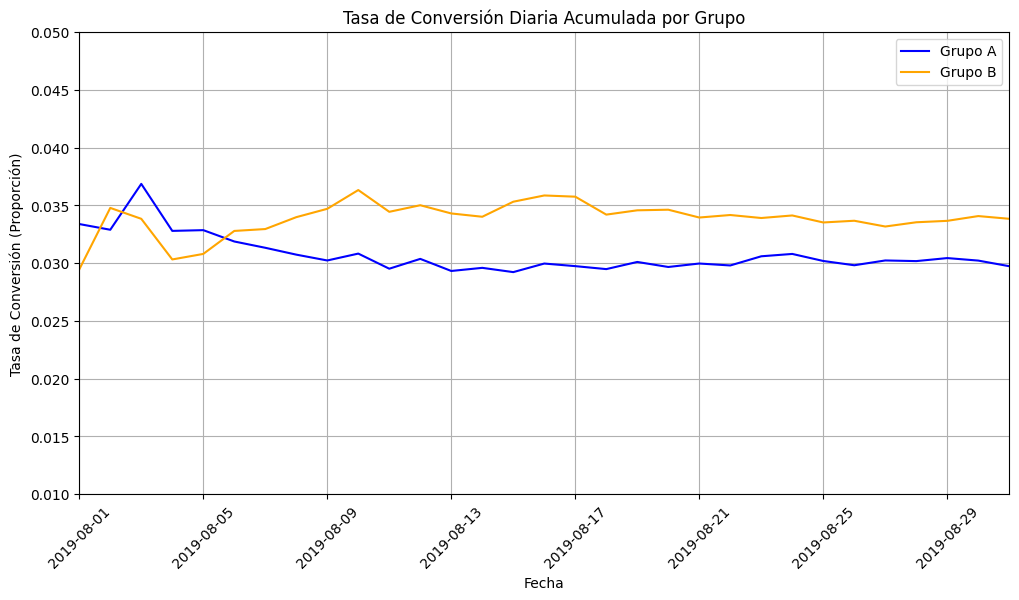

In [9]:
#Vamos a calcular la tasa de conversión diaria acumulada
import matplotlib.pyplot as plt

# Calculamos la conversión acumulada diaria (Pedidos acumulados / Visitas acumuladas)
cumulativeData['conversion'] = cumulativeData['orders'] / cumulativeData['visits']

# Separamos los datos acumulados por grupo 
cumulativeDataA = cumulativeData[cumulativeData['group'] == 'A']
cumulativeDataB = cumulativeData[cumulativeData['group'] == 'B']


plt.figure(figsize=(12, 6))
plt.plot(cumulativeDataA['date'], cumulativeDataA['conversion'], label='Grupo A', color='blue')
plt.plot(cumulativeDataB['date'], cumulativeDataB['conversion'], label='Grupo B', color='orange')

# Ajustar esta línea
plt.axis([cumulativeData['date'].min(), cumulativeData['date'].max(), 0.01, 0.05])


plt.title('Tasa de Conversión Diaria Acumulada por Grupo')
plt.xlabel('Fecha')
plt.ylabel('Tasa de Conversión (Proporción)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

A partir del 6 de agosto, las líneas se cruzan por última vez. El Grupo B toma el liderazgo y la brecha entre ambas curvas comienza a abrirse claramente.Hacia la segunda mitad del mes, ambas curvas se estabilizan por completo y marchan de forma paralela.
El Grupo A se estabiliza alrededor de una tasa del 3.0% (0.030).
El Grupo B se consolida notablemente más arriba, manteniéndose plano en torno al 3.4% (0.034). Debemos tomar en cuenta que aquí no vemos ningún pico en el intervalo de tiempo de las gráficas anteriores, esto nos puede indicar que lo que alteró la gráfica del grupo B fueron pocas personas que compraron algo muy caro y en general la tasa de conversión no se alteró.

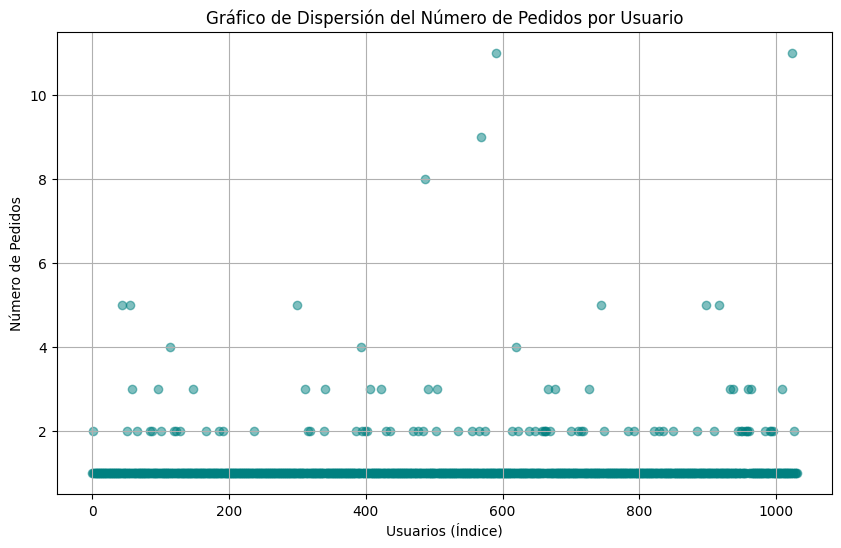

In [10]:
#Vamos a calcular y trazar el gráfico de dispersión de pedidos por usuario
# Agrupamos por usuario para contar cuántos pedidos hizo cada uno
ordersByUsers = (
    orders.groupby('visitorId', as_index=False)
    .agg({'transactionId': 'nunique'})
)
ordersByUsers.columns = ['visitorId', 'orders']

# Creamos un series
x_values = pd.Series(range(0, len(ordersByUsers)))

# Gráfico de dispersión
plt.figure(figsize=(10, 6))
plt.scatter(x_values, ordersByUsers['orders'], alpha=0.5, color='teal')

plt.title('Gráfico de Dispersión del Número de Pedidos por Usuario')
plt.xlabel('Usuarios (Índice)')
plt.ylabel('Número de Pedidos')
plt.grid(True)
plt.show()

La mayoría de los clientes sólo realiza 1 pedido,mientras que un grupo stándar realizan 2 pedidos, los que se podrían considerar como valores atípicos son los que realizan entre 3 o más pedidos. Esos usuarios que compran de 3 a 11 veces son anomalías que rompen el promedio.

In [11]:
#Vamos a calcular los percentiles 95 y 99.
import numpy as np

# Calculamos los percentiles 95 y 99 para la columna 'orders'
print(np.percentile(ordersByUsers['orders'], [95, 99]))


[2. 4.]


Estableceremos el límite en más de 2 pedidos. Cualquier usuario que haya realizado 3 o más órdenes durante el experimento será considerado un dato atípico (outlier) y será excluido de la fase final de datos filtrados.

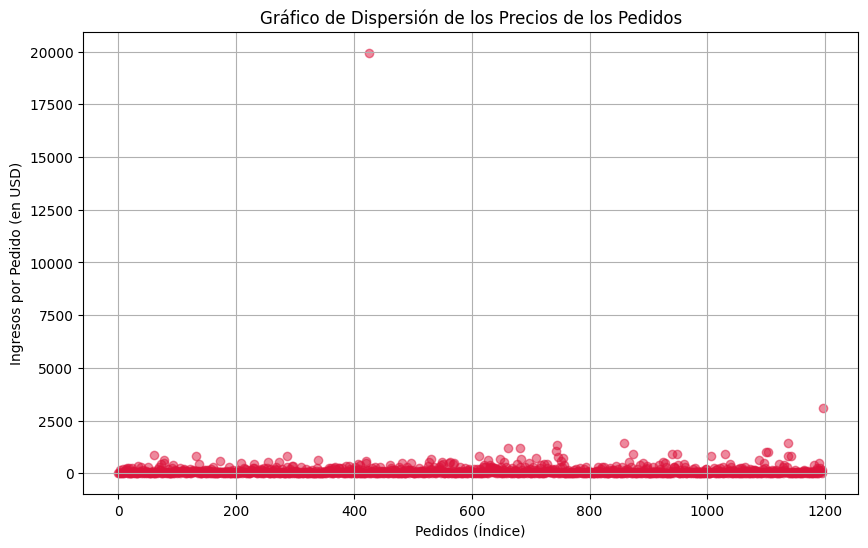

[435.54  900.904]


In [12]:
#Vamos a calcular y trazar el gráfico de dispersión de los precios de los pedidos
# Creamos un series para el eje X basada en el tamaño de la tabla orders
x_values = pd.Series(range(0, len(orders)))

# Trazamos el gráfico de dispersión de los ingresos por pedido
plt.figure(figsize=(10, 6))
plt.scatter(x_values, orders['revenue'], alpha=0.5, color='crimson')

plt.title('Gráfico de Dispersión de los Precios de los Pedidos')
plt.xlabel('Pedidos (Índice)')
plt.ylabel('Ingresos por Pedido (en USD)')
plt.grid(True)
plt.show()

# Calculamos los percentiles 95 y 99 para la columna 'revenue'
print(np.percentile(orders['revenue'], [95, 99]))

Aquí podemos observar claramente el valor atípico de 20,000 USD que fue el pico que vimos en la gráfica de ingresos y de tickt promedio. Existe otro valor atípico que es el de 3,000 USD casi al final de la gráfica, si quitamos estos dos valores podemos concluir que la mayoría de los valores se encuentran abajo de 1,000 USD.
Respecto a los percentiles:
Percentil 95 = $435.54 USD: El 95% de todas las órdenes realizadas en el sitio web tienen un valor menor o igual a $435.54 USD. Solo el 5% de los tickets supera este monto.
Percentil 99 = $900.904 USD: El 99% de los pedidos de la tienda online son de $900.91 USD o menos. Menos del 1% de los compradores gasta más de esa cantidad en una sola transacción.

Para las pruebas estadísticas utilizaremos el percentil 95%, todo pedido con valor superior a 436 USD se define como anomalía y será excluido de la muestra para el analisis.

In [13]:
#Vamos a crear dos listas con datos anómalos para excluirlos
# Identificamos los usuarios que hicieron más de 2 pedidos
usersWithManyOrders = ordersByUsers[ordersByUsers['orders'] > 2]['visitorId']

# Identificamos los usuarios que hicieron compras caras (más de $436)
usersWithExpensiveOrders = orders[orders['revenue'] > 436]['visitorId']

# Juntamos ambos grupos en una sola lista única 
abnormalUsers = (
    pd.concat([usersWithManyOrders, usersWithExpensiveOrders], axis=0)
    .drop_duplicates()
    .sort_values()
)

print(f"Total de usuarios anómalos a filtrar: {abnormalUsers.shape[0]}")

Total de usuarios anómalos a filtrar: 82


In [14]:
#Vamos a agrupar los pedidos por cada grupo y rellenar con  ceros  a los que no hicieron algun pedido
import scipy.stats as stats

ordersByUsersA = orders[orders['group']=='A'].groupby('visitorId', as_index=False).agg({'transactionId':'nunique'})
ordersByUsersA.columns = ['visitorId', 'orders']

ordersByUsersB = orders[orders['group']=='B'].groupby('visitorId', as_index=False).agg({'transactionId':'nunique'})
ordersByUsersB.columns = ['visitorId', 'orders']

# Creamos la muestra A completa: sumamos los que compraron + los que no compraron (rellenos con 0)
sampleA = pd.concat([ordersByUsersA['orders'], pd.Series(0, index=np.arange(visits[visits['group']=='A']['visits'].sum() - len(ordersByUsersA['orders'])), name='orders')], axis=0)

# Creamos la muestra B completa: sumamos los que compraron + los que no compraron (rellenos con 0)
sampleB = pd.concat([ordersByUsersB['orders'], pd.Series(0, index=np.arange(visits[visits['group']=='B']['visits'].sum() - len(ordersByUsersB['orders'])), name='orders')], axis=0)

In [16]:
#Aplicaremos la prueba estadística asumiendo que: Si el p-value es menor a 0.05, rechazamos la hipótesis nula y la diferencia es estadísticamente significativa.

# Ejecutamos la prueba de Mann-Whitney U para conversión
p_value_conv_raw = stats.mannwhitneyu(sampleA, sampleB)[1]
relative_gain_conv_raw = sampleB.mean() / sampleA.mean() - 1

print(f"P-value (Conversión en bruto): {p_value_conv_raw:.5f}")
print(f"Ganancia relativa del Grupo B: {relative_gain_conv_raw:.2%}")

# Ejecutamos la prueba de Mann-Whitney U para el tamaño de pedido
p_value_rev_raw = stats.mannwhitneyu(orders[orders['group']=='A']['revenue'], orders[orders['group']=='B']['revenue'])[1]
relative_gain_rev_raw = orders[orders['group']=='B']['revenue'].mean() / orders[orders['group']=='A']['revenue'].mean() - 1

print(f"P-value (Tamaño de pedido en bruto): {p_value_rev_raw:.5f}")
print(f"Ganancia relativa del ticket promedio en Grupo B: {relative_gain_rev_raw:.2%}")

P-value (Conversión en bruto): 0.01679
Ganancia relativa del Grupo B: 13.81%
P-value (Tamaño de pedido en bruto): 0.69152
Ganancia relativa del ticket promedio en Grupo B: 25.17%


En cuanto al comportamiento el p value (0.01679) es mucho menor que 0.05 rechazamos la hipotesis nula.Esto demuestra matemáticamente que el Grupo B es significativamente mejor para convertir visitantes en compradores que el Grupo A. No es una coincidencia: las modificaciones implementadas en la versión B lograron que la tienda online ganara un 13.81% más de clientes de forma sólida.
En cuanto al ticket promedio  el p value (0.69152) es mucho mayor que 0.05 significa que la f¿diferecnia no es estadísticamente significativa. La venta aparente del 25.17% está distorsionada por el valor atípico (20,000 USD) que encontramos en los graficos de dispersión.

In [23]:
#Vamos a calcular significacia estadística con datos filtrados
# Filtramos la conversión (con ceros) excluyendo a los usuarios anómalos
sampleAFiltered = pd.concat(
    [ordersByUsersA[np.logical_not(ordersByUsersA['visitorId'].isin(abnormalUsers))]['orders'],
     pd.Series(0, index=np.arange(visits[visits['group']=='A']['visits'].sum() - len(ordersByUsersA['orders'])), name='orders')],
    axis=0
)

sampleBFiltered = pd.concat(
    [ordersByUsersB[np.logical_not(ordersByUsersB['visitorId'].isin(abnormalUsers))]['orders'],
     pd.Series(0, index=np.arange(visits[visits['group']=='B']['visits'].sum() - len(ordersByUsersB['orders'])), name='orders')],
    axis=0
)

p_value_conv_filt = stats.mannwhitneyu(sampleAFiltered, sampleBFiltered)[1]
relative_gain_filt = sampleBFiltered.mean() / sampleAFiltered.mean() - 1

print(f"P-value (Conversión FILTRADA): {p_value_conv_filt:.5f}")
print(f"Ganancia relativa de Conversión FILTRADA en Grupo B: {relative_gain_filt:.2%}")

# Prueba de tamaño de pedido con datos filtrados
ordersFilteredA = orders[(orders['group']=='A') & (np.logical_not(orders['visitorId'].isin(abnormalUsers)))]['revenue']
ordersFilteredB = orders[(orders['group']=='B') & (np.logical_not(orders['visitorId'].isin(abnormalUsers)))]['revenue']

p_value_rev_filt = stats.mannwhitneyu(ordersFilteredA, ordersFilteredB)[1]
relative_gain_rev_filt = ordersFilteredB.mean() / ordersFilteredA.mean() - 1

print(f"P-value (Tamaño de pedido FILTRADO): {p_value_rev_filt:.5f}")
print(f"Ganancia relativa del ticket promedio FILTRADO en Grupo B: {relative_gain_rev_filt:.2%}")


P-value (Conversión FILTRADA): 0.01335
Ganancia relativa de Conversión FILTRADA en Grupo B: 17.32%
P-value (Tamaño de pedido FILTRADO): 0.74656
Ganancia relativa del ticket promedio FILTRADO en Grupo B: -3.10%


En cuanto a la conversión filtrada el p value (0.01335) sigue siendo mucho menor a 0.05 por lo que confirma que la diferencia es significativa y que la ventaja del Grupo B mejoró en un 17.32% incluso quitando los valores atípicos.
En cuanto al ticket promedio filtrado, al eliminar los usuarios atípicos la ventaja que tuvimos con los datos en bruto desapareció y ahora se volvió en una pérdida del -3.10%
En este caso como el p value(0.74656) es mucho mayor que 0.05 se confirma que no existe una diferencia significativa  y el usario típico gasta en promedio lo mismo que los de grupo A.

Conclusión:
Tras el análisis de resultados acumulados, distribución de anomalías y las pruebas de significancia estadística se toma la decisión de parar la prueba y se declara al grupo B como el ganador del experimento bajo la siguiente justificación:
Tanto en los datos en bruto como en los filtrados, el Grupo B demostró una ventaja sólida y estadísticamente significativa (p-values < 0.05). Con los datos completamente limpios de ruido, el Grupo B supera al Grupo A en un 17.32% en su tasa de conversión, consolidando una base de clientes recurrentes mucho más fuerte y estable en el tiempo, tal como se observó en la gráfica de tendencias acumuladas.
Las pruebas estadísticas demostraron que las modificaciones de la versión B no alteran significativamente el monto que gasta cada usuario por pedido (p-value de 0.74).
Dado que el ticket promedio se mantiene equivalente pero el volumen de compradores aumentó un 17.32% gracias a la mejora en la conversión, el resultado neto para la tienda online es un incremento masivo y orgánico en los ingresos a largo plazo.